In [1]:
from openai import OpenAI
from datetime import datetime
import pandas as pd
import numpy as np
import os
from datetime import datetime
from multiprocessing import Pool, cpu_count
from multiprocessing import Manager, Lock
from multiprocessing import Process
from tqdm import tqdm
import concurrent.futures
from glob import glob
import re
import glob
from multiprocessing import Process, set_start_method

In [2]:
train_df = pd.read_csv(
    '../train_50K_llm_synthetic_df.csv'
)
train_df["ref_age"] = np.floor(train_df["ref_age"]).astype(int)

test_df = pd.read_csv(
    '../test_10K_llm_synthetic_df.csv'
)
test_df["ref_age"] = np.floor(test_df["ref_age"]).astype(int)

In [3]:
print(test_df.columns)
print(train_df.columns)

Index(['sex', 'ref_age', 'diagnosis'], dtype='object')
Index(['sex', 'ref_age', 'diagnosis'], dtype='object')


In [4]:
# === Output Directory ===
save_dir_train = "/users/PDS0345/rxa615/Comorbidity Score/synthetic_data/Synthetic_Comorbidity_LLM/Deepseek/train"
os.makedirs(save_dir_train, exist_ok=True)

# === Output Directory ===
save_dir_test = "/users/PDS0345/rxa615/Comorbidity Score/synthetic_data/Synthetic_Comorbidity_LLM/Deepseek/test"
os.makedirs(save_dir_test, exist_ok=True)

In [5]:
client = OpenAI(api_key="XXX", base_url="https://api.deepseek.com")

In [6]:
# === Prompt Template ===
prompt_template = """
## Task Instruction:
You are a medically informed AI assistant trained on clinical literature and established comorbidity scoring systems, such as the **Charlson Comorbidity Index** and the **Elixhauser Comorbidity Measure**. Your task is to compute a **general-purpose multimorbidity mortality risk score** based on the patient's coexisting medical conditions and demographic data.

**Important:** Do not provide any explanation, reasoning, or justification. Only return the numeric risk score and confidence score.

## Confidence Score Instructions:
Alongside the risk score, assign a **Confidence Score** between 0 and 1 that reflects how reliable or certain your estimate is based on the given inputs.

## Output Format:
Strictly adhere to the following format:

---
**Multimorbidity Mortality Risk Score:** <numeric_score>  
**Confidence Score (0–1):** <confidence_value>
---

## Patient Input:
- Diagnoses: {diagnosis}  
- Age: {ref_age}  
- Sex: {sex}
""".strip()


In [7]:
# === Scoring Function ===
def get_comorbidity_score(patient_data, temperature=0.5):
    try:
        prompt = prompt_template.format(
            diagnosis=", ".join(patient_data["diagnosis"]),
            ref_age=patient_data["ref_age"],
            sex=patient_data["sex"]
        )
        response = client.chat.completions.create(
            model="deepseek-chat",
            messages=[
                {"role": "system", "content": "You are a helpful assistant"},
                {"role": "user", "content": prompt},
            ],
            temperature=temperature,
            stream=False
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return f"Error: {str(e)}"

import os, numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed
from threading import Lock
from tqdm import tqdm

# global progress objects (set in runner)
_pbar = None
_pbar_lock = Lock()

def process_partition(df_partition, part_id, save_dir):
    output_file = os.path.join(save_dir, f"cci_output_part{part_id}.csv")
    os.makedirs(save_dir, exist_ok=True)
    with open(output_file, "w") as f:
        f.write("participant_id\tscore_output\n")

    # NO tqdm here to avoid multi-bar collisions
    count = 0
    for row in df_partition.itertuples(index=False):
        diagnoses = [d.strip() for d in row.diagnosis.split(";") if d.strip()]
        patient_data = {"diagnosis": diagnoses, "ref_age": row.ref_age, "sex": row.sex}
        score_output = get_comorbidity_score(patient_data)
        with open(output_file, "a") as f:
            f.write(f"{row.participant_id}\t{score_output}\n")

        count += 1
        # update the single global bar safely
        if _pbar is not None:
            with _pbar_lock:
                _pbar.update(1)

def run_parallel_scoring(comorbidity_df, save_dir, n_parts=20, max_workers=50):
    os.makedirs(save_dir, exist_ok=True)
    partitions = np.array_split(comorbidity_df, n_parts)

    global _pbar
    total_rows = len(comorbidity_df)
    _pbar = tqdm(total=total_rows, unit="rows", desc="Scoring", dynamic_ncols=True)

    try:
        with ThreadPoolExecutor(max_workers=max_workers) as ex:
            futures = [ex.submit(process_partition, part_df.copy(), i + 1, save_dir)
                       for i, part_df in enumerate(partitions)]
            for f in as_completed(futures):
                f.result()  # re-raise exceptions
    finally:
        _pbar.close()
        _pbar = None


In [8]:
import os, numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed
from threading import Lock
from tqdm import tqdm

# global progress objects (set in runner)
_pbar = None
_pbar_lock = Lock()

def process_partition(df_partition, part_id, save_dir):
    output_file = os.path.join(save_dir, f"cci_output_part{part_id}.csv")
    os.makedirs(save_dir, exist_ok=True)
    with open(output_file, "w") as f:
        f.write("participant_id\tscore_output\n")

    # NO tqdm here to avoid multi-bar collisions
    count = 0
    for row in df_partition.itertuples(index=False):
        diagnoses = [d.strip() for d in row.diagnosis.split(";") if d.strip()]
        patient_data = {"diagnosis": diagnoses, "ref_age": row.ref_age, "sex": row.sex}
        score_output = get_comorbidity_score(patient_data)
        with open(output_file, "a") as f:
            f.write(f"{row.participant_id}\t{score_output}\n")

        count += 1
        # update the single global bar safely
        if _pbar is not None:
            with _pbar_lock:
                _pbar.update(1)

def run_parallel_scoring(comorbidity_df, save_dir, n_parts=20, max_workers=50):
    os.makedirs(save_dir, exist_ok=True)
    partitions = np.array_split(comorbidity_df, n_parts)

    global _pbar
    total_rows = len(comorbidity_df)
    _pbar = tqdm(total=total_rows, unit="rows", desc="Scoring", dynamic_ncols=True)

    try:
        with ThreadPoolExecutor(max_workers=max_workers) as ex:
            futures = [ex.submit(process_partition, part_df.copy(), i + 1, save_dir)
                       for i, part_df in enumerate(partitions)]
            for f in as_completed(futures):
                f.result()  # re-raise exceptions
    finally:
        _pbar.close()
        _pbar = None


In [9]:
# If participant_id is missing, create one
if "participant_id" not in test_df.columns:
    test_df = test_df.reset_index().rename(columns={"index": "participant_id"})

# === Run scoring in parallel ===
run_parallel_scoring(test_df, save_dir_test, n_parts=20, max_workers=0)

/users/PDS0345/rxa615/.local/lib/python3.9/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
Scoring: 100%|██████████| 10000/10000 [39:51<00:00,  4.18rows/s] 


In [11]:
# If participant_id is missing, create one
if "participant_id" not in train_df.columns:
    train_df = train_df.reset_index().rename(columns={"index": "participant_id"})

# === Run scoring in parallel ===
run_parallel_scoring(train_df, save_dir_train, n_parts=50)

In [15]:
import os, re, glob
import pandas as pd

base_path = "/users/PDS0345/rxa615/Comorbidity Score/synthetic_data/Synthetic_Comorbidity_LLM/Deepseek/train"


# Regexes
start_rx = re.compile(r'^(\d+)\t---\s*$')   # record start: <participant_id>\t---
score_rx = re.compile(r"Risk\s*Score[^0-9]*([0-9]+(?:\.[0-9]+)?)", re.I | re.S)
conf_rx  = re.compile(r"Confidence\s*Score[^0-9]*([0-9]+(?:\.[0-9]+)?)", re.I | re.S)

def extract_scores(text):
    if text is None:
        return None, None
    t = str(text).replace('**', '').replace('–', '-').replace('—', '-').strip()
    # drop standalone --- lines
    t = "\n".join([ln for ln in t.splitlines() if ln.strip() != '---']).strip()
    m1 = score_rx.search(t)
    m2 = conf_rx.search(t)
    if m1 and m2:
        try:
            return float(m1.group(1)), float(m2.group(1))
        except:
            pass
    # fallback: first two numbers
    nums = re.findall(r"(?<!\w)([0-9]+(?:\.[0-9]+)?)", t)
    if len(nums) >= 2:
        return float(nums[0]), float(nums[1])
    return None, None

def parse_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [ln.rstrip("\n") for ln in f]

    # Skip header if present (e.g., "participant_id\tscore_output")
    idx = 1 if lines and ("\t" in lines[0] and "score_output" in lines[0].lower()) else 0

    while idx < len(lines):
        m = start_rx.match(lines[idx])
        if not m:
            idx += 1
            continue
        pid = m.group(1)
        idx += 1
        block = []
        # accumulate until next "<digits>\t---" or EOF
        while idx < len(lines) and not start_rx.match(lines[idx]):
            block.append(lines[idx])
            idx += 1
        blob = "\n".join(block).strip()
        sc, cf = extract_scores(blob)
        if sc is not None and cf is not None:
            rows.append((pid, sc, cf))
    return rows

# Collect files and sort by part number
files = sorted(
    glob.glob(os.path.join(base_path, "cci_output_part*")),
    key=lambda p: int(re.search(r'part(\d+)', os.path.basename(p)).group(1)) if re.search(r'part(\d+)', os.path.basename(p)) else 0
)

if not files:
    raise FileNotFoundError(f"No files matching cci_output_part* in {base_path}")

all_rows = []
for i, fp in enumerate(files, 1):
    recs = parse_file(fp)
    print(f"[{i}/{len(files)}] {os.path.basename(fp)} -> parsed {len(recs)} rows")
    all_rows.extend(recs)

if not all_rows:
    raise ValueError("No parsed rows. The file structure might differ; send 30–40 raw lines if so.")

final_df = pd.DataFrame(all_rows, columns=["participant_id", "score", "confidence_score"])
final_df = final_df.drop_duplicates(subset=["participant_id"], keep="first")
print(f"\nFinal shape: {final_df.shape}")
print(f"Score range: {final_df['score'].min()} – {final_df['score'].max()}")
print(f"Confidence range: {final_df['confidence_score'].min()} – {final_df['confidence_score'].max()}")

out_csv = os.path.join(base_path, "deepseek_train_merged.csv")
final_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")


[1/50] cci_output_part1.csv -> parsed 1000 rows
[2/50] cci_output_part2.csv -> parsed 1000 rows
[3/50] cci_output_part3.csv -> parsed 1000 rows
[4/50] cci_output_part4.csv -> parsed 1000 rows
[5/50] cci_output_part5.csv -> parsed 1000 rows
[6/50] cci_output_part6.csv -> parsed 1000 rows
[7/50] cci_output_part7.csv -> parsed 1000 rows
[8/50] cci_output_part8.csv -> parsed 1000 rows
[9/50] cci_output_part9.csv -> parsed 1000 rows
[10/50] cci_output_part10.csv -> parsed 945 rows
[11/50] cci_output_part11.csv -> parsed 1000 rows
[12/50] cci_output_part12.csv -> parsed 1000 rows
[13/50] cci_output_part13.csv -> parsed 1000 rows
[14/50] cci_output_part14.csv -> parsed 1000 rows
[15/50] cci_output_part15.csv -> parsed 1000 rows
[16/50] cci_output_part16.csv -> parsed 1000 rows
[17/50] cci_output_part17.csv -> parsed 1000 rows
[18/50] cci_output_part18.csv -> parsed 1000 rows
[19/50] cci_output_part19.csv -> parsed 1000 rows
[20/50] cci_output_part20.csv -> parsed 1000 rows
[21/50] cci_output_

Text(0, 0.5, 'Frequency')

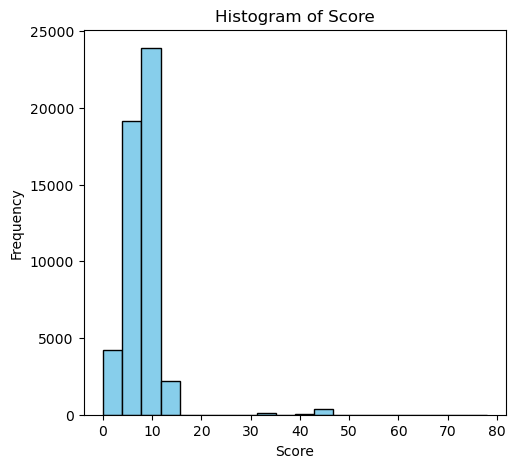

In [16]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Histogram for score
plt.subplot(1, 2, 1)
plt.hist(final_df['score'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Score')
plt.xlabel('Score')
plt.ylabel('Frequency')


In [17]:
import os, re, glob
import pandas as pd

base_path = "/users/PDS0345/rxa615/Comorbidity Score/synthetic_data/Synthetic_Comorbidity_LLM/Deepseek/test"

# Regexes
start_rx = re.compile(r'^(\d+)\t---\s*$')   # record start: <participant_id>\t---
score_rx = re.compile(r"Risk\s*Score[^0-9]*([0-9]+(?:\.[0-9]+)?)", re.I | re.S)
conf_rx  = re.compile(r"Confidence\s*Score[^0-9]*([0-9]+(?:\.[0-9]+)?)", re.I | re.S)

def extract_scores(text):
    if text is None:
        return None, None
    t = str(text).replace('**', '').replace('–', '-').replace('—', '-').strip()
    # drop standalone --- lines
    t = "\n".join([ln for ln in t.splitlines() if ln.strip() != '---']).strip()
    m1 = score_rx.search(t)
    m2 = conf_rx.search(t)
    if m1 and m2:
        try:
            return float(m1.group(1)), float(m2.group(1))
        except:
            pass
    # fallback: first two numbers
    nums = re.findall(r"(?<!\w)([0-9]+(?:\.[0-9]+)?)", t)
    if len(nums) >= 2:
        return float(nums[0]), float(nums[1])
    return None, None

def parse_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [ln.rstrip("\n") for ln in f]

    # Skip header if present (e.g., "participant_id\tscore_output")
    idx = 1 if lines and ("\t" in lines[0] and "score_output" in lines[0].lower()) else 0

    while idx < len(lines):
        m = start_rx.match(lines[idx])
        if not m:
            idx += 1
            continue
        pid = m.group(1)
        idx += 1
        block = []
        # accumulate until next "<digits>\t---" or EOF
        while idx < len(lines) and not start_rx.match(lines[idx]):
            block.append(lines[idx])
            idx += 1
        blob = "\n".join(block).strip()
        sc, cf = extract_scores(blob)
        if sc is not None and cf is not None:
            rows.append((pid, sc, cf))
    return rows

# Collect files and sort by part number
files = sorted(
    glob.glob(os.path.join(base_path, "cci_output_part*")),
    key=lambda p: int(re.search(r'part(\d+)', os.path.basename(p)).group(1)) if re.search(r'part(\d+)', os.path.basename(p)) else 0
)

if not files:
    raise FileNotFoundError(f"No files matching cci_output_part* in {base_path}")

all_rows = []
for i, fp in enumerate(files, 1):
    recs = parse_file(fp)
    print(f"[{i}/{len(files)}] {os.path.basename(fp)} -> parsed {len(recs)} rows")
    all_rows.extend(recs)

if not all_rows:
    raise ValueError("No parsed rows. The file structure might differ; send 30–40 raw lines if so.")

final_df = pd.DataFrame(all_rows, columns=["participant_id", "score", "confidence_score"])
final_df = final_df.drop_duplicates(subset=["participant_id"], keep="first")
print(f"\nFinal shape: {final_df.shape}")
print(f"Score range: {final_df['score'].min()} – {final_df['score'].max()}")
print(f"Confidence range: {final_df['confidence_score'].min()} – {final_df['confidence_score'].max()}")

out_csv = os.path.join(base_path, "deepseek_test_merged.csv")
final_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")


[1/20] cci_output_part1.csv -> parsed 500 rows
[2/20] cci_output_part2.csv -> parsed 500 rows
[3/20] cci_output_part3.csv -> parsed 500 rows
[4/20] cci_output_part4.csv -> parsed 500 rows
[5/20] cci_output_part5.csv -> parsed 500 rows
[6/20] cci_output_part6.csv -> parsed 500 rows
[7/20] cci_output_part7.csv -> parsed 500 rows
[8/20] cci_output_part8.csv -> parsed 500 rows
[9/20] cci_output_part9.csv -> parsed 500 rows
[10/20] cci_output_part10.csv -> parsed 500 rows
[11/20] cci_output_part11.csv -> parsed 500 rows
[12/20] cci_output_part12.csv -> parsed 500 rows
[13/20] cci_output_part13.csv -> parsed 500 rows
[14/20] cci_output_part14.csv -> parsed 500 rows
[15/20] cci_output_part15.csv -> parsed 500 rows
[16/20] cci_output_part16.csv -> parsed 500 rows
[17/20] cci_output_part17.csv -> parsed 500 rows
[18/20] cci_output_part18.csv -> parsed 500 rows
[19/20] cci_output_part19.csv -> parsed 500 rows
[20/20] cci_output_part20.csv -> parsed 500 rows

Final shape: (10000, 3)
Score range: 

Text(0, 0.5, 'Frequency')

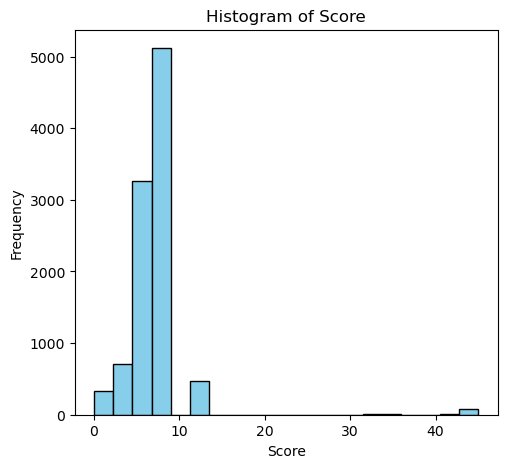

In [18]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Histogram for score
plt.subplot(1, 2, 1)
plt.hist(final_df['score'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Score')
plt.xlabel('Score')
plt.ylabel('Frequency')
